In [1]:
import hoda
import tensorly as tl

print(tl.get_backend())
%pip install toeplitzlda
%pip freeze | grep moabb

cupy

[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
moabb==1.0.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from moabb.evaluations import WithinSessionEvaluation
tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
datasets = [
    #BI2012(),
    #BI2013a(),
    #BI2014a(),
    #BI2014b(),
    #BI2015a(),
    #BI2015b(),
    BNCI2014_008(),
    #BNCI2014_009(),
    #BNCI2015_003(),
    #Cattan2019_VR(),
    #EPFLP300(),
    #Huebner2017(),
    #Huebner2018(),
    #Lee2019_ERP(),
    #Sosulski2019(),
]

evaluation = WithinSessionEvaluation(
    paradigm=paradigm,
    datasets=datasets,
    suffix="hoda_erp",
    overwrite=True,
    random_state=42,
    n_jobs=5,
)

<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(


In [3]:
from sklearn.pipeline import make_pipeline, Pipeline
from hoda.hoda import HODA, BTTDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from hoda.classification import Vectorize, SelectFweAtLeastOne, ToeplitzLDAWrapper
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import FunctionTransformer
import numpy as np
from hoda.tensorize import hankel_tensor

pipelines = dict()

hoda_params=dict(
    max_iter=128,
    tol=1e-16,
    init ='mlsvd',
    shrinkage='lw',
    toeplitz=(1,),
    obj='rt',
    taper=False,
    extra_train_info=False,
    verbose=False,  
)
"""
pipelines['sLDA'] = make_pipeline(
        Vectorize(),
        LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)
pipelines['tLDA'] = ToeplitzLDAWrapper()
"""
pipelines['HODA_lobpcg'] =Pipeline([
        ('hoda', HODA(
            rank=4,
            solver='lobpcg',
            **hoda_params
        )),
        ('vec', Vectorize()),
        ('lda', LinearDiscriminantAnalysis())
    ])
pipelines['HODA_lanczos'] =Pipeline([
        ('hoda', HODA(
            rank=4,
            solver='lanczos',
            **hoda_params
        )),
        ('vec', Vectorize()),
        ('lda', LinearDiscriminantAnalysis())
    ])
pipelines['HODA_svd'] =Pipeline([
        ('hoda', HODA(
            rank=4,
            solver='svd',
            **hoda_params
        )),
        ('vec', Vectorize()),
        ('lda', LinearDiscriminantAnalysis())
    ])

hoda_params_no_toep = hoda_params.copy()
hoda_params_no_toep['toeplitz']=None
pipelines['bttda_fixed'] = Pipeline([
        ('bttda', BTTDA(
            ranks=[4]*8,
            hoda_params=hoda_params_no_toep,
            verbose=False,
            extra_train_info=False,
        )),
        ('vec', Vectorize()),
        ('lda', LinearDiscriminantAnalysis())
    ])

pipelines['bttda_fixed_toep'] = Pipeline([
        ('bttda', BTTDA(
            ranks=[4]*8,
            hoda_params=hoda_params,
            verbose=False,
            extra_train_info=False,
        )),
        ('vec', Vectorize()),
        ('lda', LinearDiscriminantAnalysis())
    ])


In [4]:
#import warnings
#warnings.filterwarnings("ignore")

results = evaluation.process(pipelines)

BNCI2014-008-WithinSession:   0%|                                                               | 0/8 [00:00<?, ?it/s]

No hdf5_path provided, models will not be saved.


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:394: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pic

No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.


BNCI2014-008-WithinSession:  12%|██████▉                                                | 1/8 [01:06<07:47, 66.73s/it]/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:394: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))


...

BNCI2014-008-WithinSession:  75%|█████████████████████████████████████████▎             | 6/8 [06:23<02:11, 65.92s/it]/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:394: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))


No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.


BNCI2014-008-WithinSession:  88%|████████████████████████████████████████████████▏      | 7/8 [07:23<01:04, 64.09s/it]/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:394: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))


No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.
No hdf5_path provided, models will not be saved.


BNCI2014-008-WithinSession: 100%|███████████████████████████████████████████████████████| 8/8 [08:20<00:00, 62.58s/it]


In [9]:
results

,score,time,samples,subject,session,channels,n_sessions,dataset,pipeline
0,0.826722,0.761901,4200.0,1,0,8,1,BNCI2014-008,HODA_lanczos
1,0.812753,0.521048,4200.0,2,0,8,1,BNCI2014-008,HODA_lanczos
2,0.889514,0.595214,4200.0,3,0,8,1,BNCI2014-008,HODA_lanczos
3,0.818267,0.459547,4200.0,4,0,8,1,BNCI2014-008,HODA_lanczos
4,0.814298,0.913370,4200.0,5,0,8,1,BNCI2014-008,HODA_lanczos
5,0.884994,0.698357,4200.0,6,0,8,1,BNCI2014-008,HODA_lanczos
6,0.858167,0.525910,4200.0,7,0,8,1,BNCI2014-008,HODA_lanczos
7,0.953922,0.434762,4200.0,8,0,8,1,BNCI2014-008,HODA_lanczos
8,0.847916,4.263270,4200.0,1,0,8,1,BNCI2014-008,bttda_fixed_toep
9,0.827498,4.293157,4200.0,2,0,8,1,BNCI2014-008,bttda_fixed_toep


(0.5, 1.0)

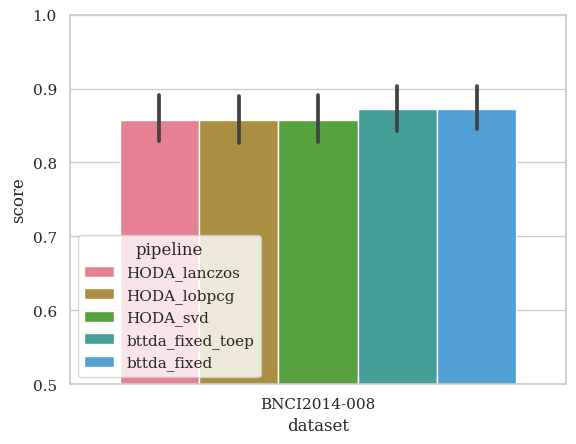

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

order = results.groupby('pipeline')
order = order.score.aggregate('mean')
order = order.sort_values()

sns.barplot(
     data=results,
    y="score", x="dataset", hue="pipeline", hue_order=order.index,
)
plt.ylim([.5,1])

/usr/local/lib/python3.10/dist-packages/moabb/analysis/meta_analysis.py:205: RuntimeWarning: invalid value encountered in scalar divide
  diffs = diffs.mean() / diffs.std()


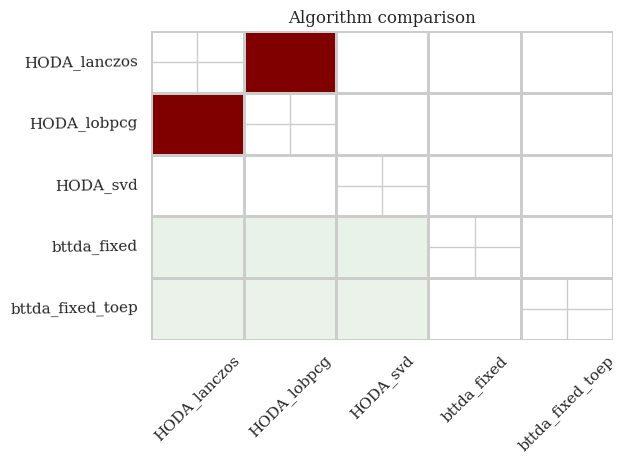

In [14]:
from moabb.analysis.meta_analysis import compute_dataset_statistics, find_significant_differences
from moabb.analysis.plotting import summary_plot
import matplotlib.pyplot as plt

stats = compute_dataset_statistics(results)
P, T = find_significant_differences(stats)
_ = summary_plot(P, T)

/usr/local/lib/python3.10/dist-packages/pandas/plotting/_matplotlib/core.py:1259: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(


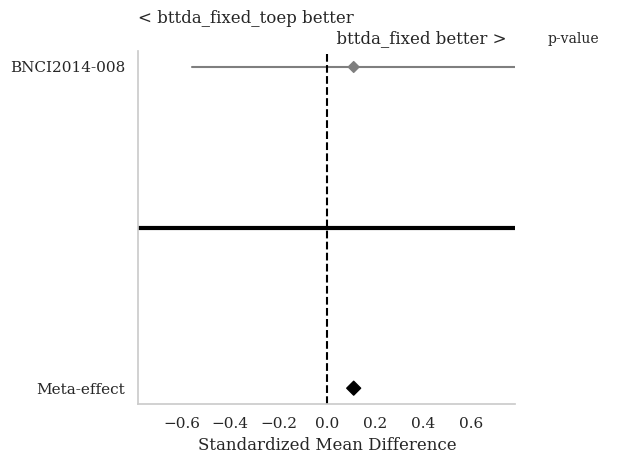

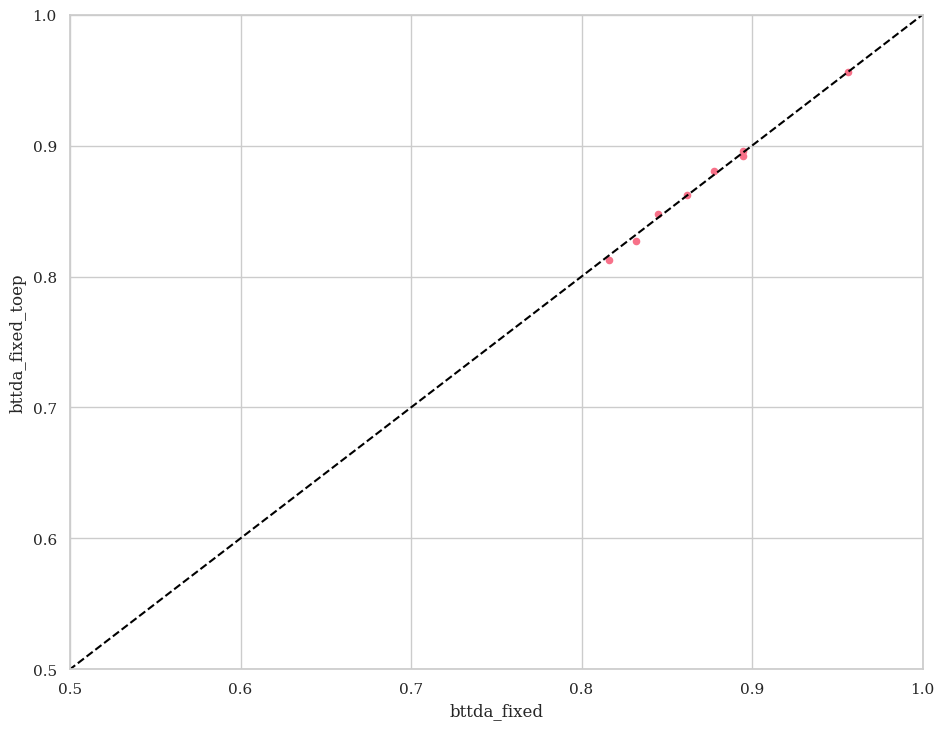

In [16]:
from moabb.analysis.plotting import meta_analysis_plot, paired_plot
_ = meta_analysis_plot(stats, 'bttda_fixed', 'bttda_fixed_toep')
_  = paired_plot(results, 'bttda_fixed', 'bttda_fixed_toep')